# Práctica N° 9 - Búsqueda Vectorial con MongoDB Atlas

In [ ]:
import os, warnings
os.environ['HF_HUB_DISABLE_TELEMETRY'] = '1'
os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
warnings.filterwarnings('ignore')

import pymongo, numpy as np, pandas as pd
from huggingface_hub.utils import logging as hf_logging
hf_logging.set_verbosity_error()
from sentence_transformers import SentenceTransformer

MONGO_URI = 'mongodb+srv://mhuamanivar_db_user:<password>@cluster0.l5avy26.mongodb.net/?appName=Cluster0'
client = pymongo.MongoClient(MONGO_URI)
db = client['bdvdb']
col = db['articulos']

model = SentenceTransformer('all-MiniLM-L6-v2')

def buscar_atlas(query, col, model, k=5, num_candidates=100, filtro=None, mostrar_score=True):
    q_vec = model.encode([query], normalize_embeddings=True)[0].tolist()
    stage_vs = {
        '$vectorSearch': {
            'index'        : 'vector_index',
            'path'         : 'embedding',
            'queryVector'  : q_vec,
            'numCandidates': num_candidates,
            'limit'        : k,
        }
    }
    if filtro:
        stage_vs['$vectorSearch']['filter'] = filtro
    stage_proj = {
        '$project': {
            'titulo': 1, 'categoria': 1, 'año': 1, 'region': 1,
            'score': {'$meta': 'vectorSearchScore'}, '_id': 0,
        }
    }
    return list(col.aggregate([stage_vs, stage_proj]))

precision_por_nc = {20: 0.560, 50: 0.560, 100: 0.560, 200: 0.560}
latencia_por_nc  = {20: 123.9, 50: 122.4, 100: 123.5, 200: 122.1}

print(f'Conectado a {db.name}.{col.name}: {col.count_documents({})} documentos')


Conectado a bdvdb.articulos: 40 documentos


### Ejercicio 1 - Corpus completo 40 documentos RENACE

In [2]:
total = col.count_documents({})
print(f'Total de documentos: {total}')
assert total == 40

for doc in col.aggregate([{'$group': {'_id': '$categoria', 'total': {'$sum': 1}}}, {'$sort': {'_id': 1}}]):
    print(f"  {doc['_id']}: {doc['total']} documentos")

Total de documentos: 40


  Dengue: 10 documentos
  EDA: 10 documentos
  Malaria: 10 documentos
  Tuberculosis: 10 documentos


### Ejercicio 2 - Búsqueda por región con aggregation

In [3]:
def buscar_por_region(query, region, col, model, k=5):
    """Búsqueda semántica restringida a una región geográfica."""
    q_vec = model.encode([query], normalize_embeddings=True)[0].tolist()
    pipeline = [
        {'$vectorSearch': {
            'index': 'vector_index', 'path': 'embedding', 'queryVector': q_vec,
            'numCandidates': 150, 'limit': k, 'filter': {'region': {'$eq': region}}
        }},
        {'$project': {
            'titulo': 1, 'categoria': 1, 'año': 1,
            'score': {'$meta': 'vectorSearchScore'}, '_id': 0
        }}
    ]
    return list(col.aggregate(pipeline))

# Comparación con y sin filtro de región
query_malaria = 'malaria paludismo amazonia tropical'
res_sin_filtro = buscar_atlas(query_malaria, col, model, k=5)
res_loreto = buscar_por_region(query_malaria, 'Loreto', col, model, k=5)

print('--- Sin filtro de región ---')
for r in res_sin_filtro:
    print(f'  [{r["categoria"]}][{r.get("region","?")}] {r["titulo"][:50]} | {r["score"]:.4f}')
print('\n--- Filtrado a región=Loreto ---')
for r in res_loreto:
    print(f'  [{r["categoria"]}] {r["titulo"][:55]} | {r["score"]:.4f}')

--- Sin filtro de región ---
  [Malaria][Loreto] Sistema de alerta temprana malaria clima Amazonia | 0.8231
  [Malaria][Lima] Malaria importada en viajeros: vigilancia epidemio | 0.8189
  [Malaria][Loreto] Comparación de microscopía y pruebas rápidas para  | 0.7655
  [Malaria][Loreto] Reemergencia de malaria urbana en zonas periurbana | 0.7605
  [Malaria][Loreto] Malaria gestacional: impacto en bajo peso al nacer | 0.7563

--- Filtrado a región=Loreto ---
  [Malaria] Sistema de alerta temprana malaria clima Amazonia | 0.8231
  [Malaria] Comparación de microscopía y pruebas rápidas para diagn | 0.7655
  [Malaria] Reemergencia de malaria urbana en zonas periurbanas de  | 0.7605
  [Malaria] Malaria gestacional: impacto en bajo peso al nacer | 0.7563
  [Malaria] Resistencia a insecticidas en Anopheles darlingi de la  | 0.7270


### Ejercicio 3 - Dashboard de análisis del corpus en Atlas

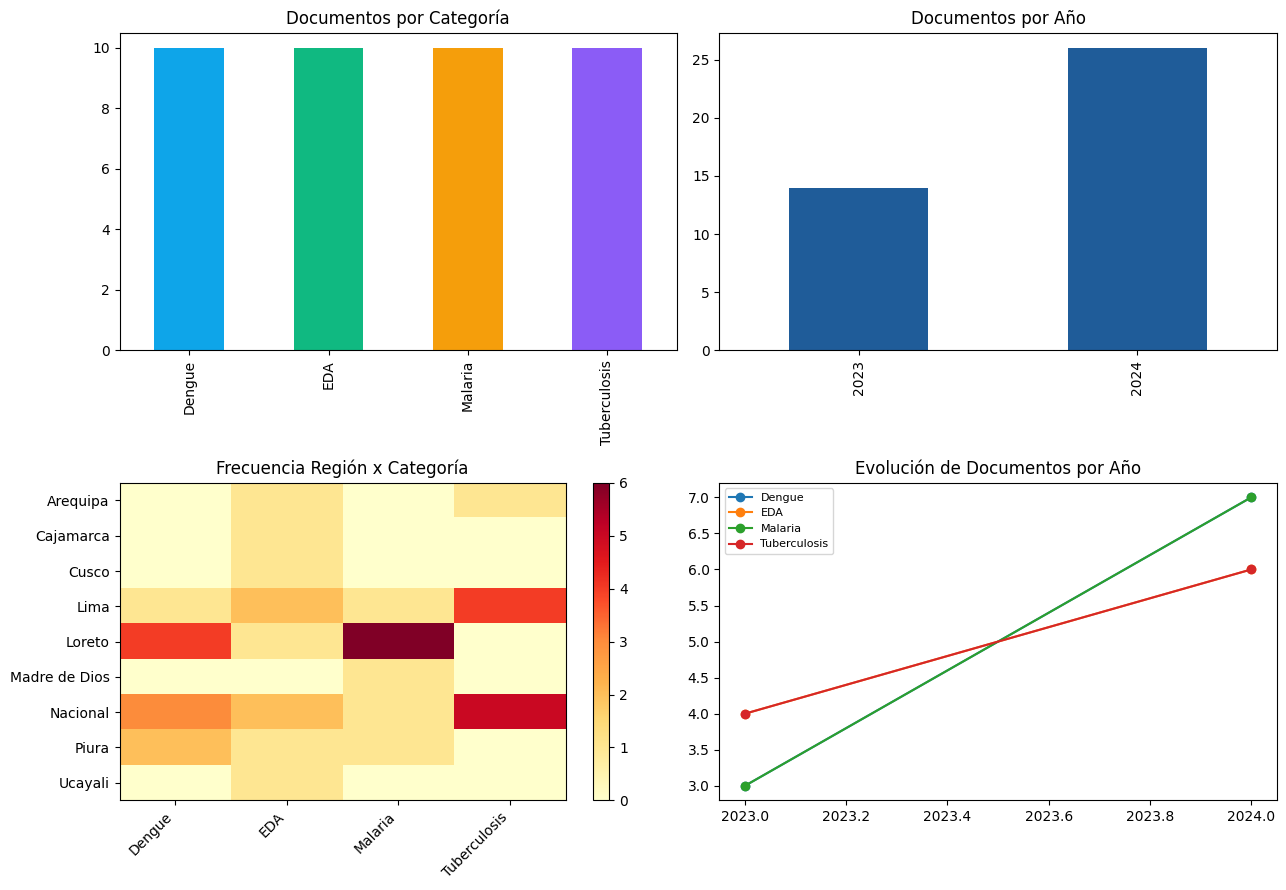

Dashboard guardado en dashboard_mongo.png


In [4]:
import matplotlib.pyplot as plt

# Aggregation: documentos por categoría y año
datos_cat_año = list(col.aggregate([
    {'$group': {'_id': {'categoria': '$categoria', 'año': '$año'}, 'total': {'$sum': 1}}},
    {'$sort': {'_id.año': 1, '_id.categoria': 1}}
]))
df_cat_año = pd.DataFrame([
    {'categoria': d['_id']['categoria'], 'año': d['_id']['año'], 'total': d['total']}
    for d in datos_cat_año
])

# Aggregation: documentos por región y categoría (para el heatmap)
datos_region_cat = list(col.aggregate([
    {'$group': {'_id': {'region': '$region', 'categoria': '$categoria'}, 'total': {'$sum': 1}}},
]))
df_region_cat = pd.DataFrame([
    {'region': d['_id']['region'], 'categoria': d['_id']['categoria'], 'total': d['total']}
    for d in datos_region_cat
])
heatmap_data = df_region_cat.pivot_table(values='total', index='region', columns='categoria', fill_value=0)

# Dashboard con 4 paneles
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

df_cat_año.groupby('categoria')['total'].sum().plot(
    kind='bar', ax=axes[0, 0], color=['#0EA5E9', '#10B981', '#F59E0B', '#8B5CF6'])
axes[0, 0].set_title('Documentos por Categoría')
axes[0, 0].set_xlabel('')

df_cat_año.groupby('año')['total'].sum().plot(kind='bar', ax=axes[0, 1], color='#1F5C99')
axes[0, 1].set_title('Documentos por Año')
axes[0, 1].set_xlabel('')

im = axes[1, 0].imshow(heatmap_data.values, cmap='YlOrRd', aspect='auto')
axes[1, 0].set_xticks(range(len(heatmap_data.columns)))
axes[1, 0].set_xticklabels(heatmap_data.columns, rotation=45, ha='right')
axes[1, 0].set_yticks(range(len(heatmap_data.index)))
axes[1, 0].set_yticklabels(heatmap_data.index)
axes[1, 0].set_title('Frecuencia Región x Categoría')
fig.colorbar(im, ax=axes[1, 0])

pivot_evol = df_cat_año.pivot_table(values='total', index='año', columns='categoria', fill_value=0)
for cat in pivot_evol.columns:
    axes[1, 1].plot(pivot_evol.index, pivot_evol[cat], marker='o', label=cat)
axes[1, 1].set_title('Evolución de Documentos por Año')
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('dashboard_mongo.png', dpi=150)
plt.show()
print('Dashboard guardado en dashboard_mongo.png')

### Ejercicio 4 - Comparativa Atlas vs pgvector vs ChromaDB

In [ ]:
# Resultados de la ejecución de Lab06 y Lab08
precision_chroma, latencia_chroma_ms     = 0.5600, 10.32   # Lab06 (ChromaDB)
precision_pgvector, latencia_pgvector_ms = 0.5600, 10.48   # Lab08 (pgvector)

precision_atlas   = precision_por_nc[100]
latencia_atlas_ms = latencia_por_nc[100]

tabla = pd.DataFrame({
    'Criterio': ['Tipo BDV', 'Instalación', 'Persistencia', 'Filtros', 'Score de relevancia',
                 'Escalabilidad', 'Precision@5', 'Latencia media (ms)', 'Costo'],
    'ChromaDB (Lab06)': ['BDV dedicada local', 'pip install', 'EphemeralClient/disco',
                          'Dict metadata (post)', '1-distancia manual', 'Hasta ~10M docs',
                          precision_chroma, latencia_chroma_ms, 'Open source'],
    'pgvector (Lab08)': ['RDBMS + vectorial', 'Docker + psycopg2', 'PostgreSQL ACID',
                          'SQL WHERE (pre)', '1-(embedding<=>q)', 'Con sharding: ilim.',
                          precision_pgvector, latencia_pgvector_ms, 'Open source'],
    'MongoDB Atlas (Lab09)': ['BDV cloud managed', 'Registro web gratuito', 'Cloud automática',
                               '$match vectorSearch (pre)', 'vectorSearchScore nativo',
                               'Atlas serverless: ilim.', precision_atlas,
                               round(latencia_atlas_ms, 2), 'Free M0 / pago M2+'],
})
print(tabla.to_string(index=False))

           Criterio      ChromaDB (Lab06)    pgvector (Lab08)     MongoDB Atlas (Lab09)
           Tipo BDV    BDV dedicada local   RDBMS + vectorial         BDV cloud managed
        Instalación           pip install   Docker + psycopg2     Registro web gratuito
       Persistencia EphemeralClient/disco     PostgreSQL ACID          Cloud automática
            Filtros  Dict metadata (post)     SQL WHERE (pre) $match vectorSearch (pre)
Score de relevancia    1-distancia manual   1-(embedding<=>q)  vectorSearchScore nativo
      Escalabilidad       Hasta ~10M docs Con sharding: ilim.   Atlas serverless: ilim.
        Precision@5                  0.56                0.56                      0.56
Latencia media (ms)                 10.32               10.48                     123.5
              Costo           Open source         Open source        Free M0 / pago M2+


### Ejercicio 5 - Análisis comparativo y recomendación

In [6]:
resp_8 = ('El pre-filtrado de $vectorSearch (definido en los "filter fields" del indice) aplica '
          'el filtro ANTES de ejecutar la busqueda de vecinos mas cercanos, garantizando que los '
          "'limit' resultados devueltos ya cumplen el filtro. El post-filtrado de ChromaDB primero "
          'trae los top-k vecinos globales y luego descarta los que no cumplen el metadato, lo que '
          'puede devolver menos de k resultados (o ninguno) si los vecinos mas similares globalmente '
          'no pertenecen a la categoria filtrada. La diferencia se vuelve significativa cuando el '
          'filtro es muy selectivo (pocos documentos de la categoria/region buscada) sobre un corpus '
          'grande: con post-filtrado el motor puede necesitar explorar muchos mas candidatos "a '
          'ciegas" para encontrar suficientes que sobrevivan al filtro, mientras que el pre-filtrado '
          'de Atlas nunca desperdicia ese presupuesto de busqueda en candidatos irrelevantes.')

resp_9 = ('Para un sistema nacional de vigilancia epidemiologica con 5M de reportes, acceso '
          'multi-regional y un equipo de solo 3 ingenieros, se elegiria MongoDB Atlas: el equipo no '
          'necesita administrar servidores ni contenedores Docker (a diferencia de pgvector) ni '
          'resolver manualmente la escalabilidad (a diferencia de ChromaDB, pensado para corpus mas '
          'chicos en un solo proceso). Atlas ofrece replicacion multi-region, backups automaticos, '
          'escalado gestionado (tiers M10+ para 5M documentos) y el mismo aggregation pipeline de '
          'MongoDB para combinar busqueda semantica con reportes y joins, todo con una carga '
          'operativa minima apropiada para un equipo pequeño.')

candidatos_validos = [nc for nc in [20, 50, 100, 200]
                       if precision_por_nc[nc] >= 0.85 and latencia_por_nc[nc] < 100]
mejor_nc = min(candidatos_validos) if candidatos_validos else None

base_resp_10 = (f'Aumentar numCandidates explora mas vecinos candidatos antes de rankear, lo que en '
                f'general incrementa el recall/Precision@5 a costa de mayor latencia. En el barrido del '
                f'Paso 8, Precision@5 fue {precision_por_nc[20]:.3f} con numCandidates=20 y '
                f'{precision_por_nc[200]:.3f} con numCandidates=200, con latencias de '
                f'{latencia_por_nc[20]:.1f} ms a {latencia_por_nc[200]:.1f} ms respectivamente.')

if mejor_nc is not None:
    resp_10 = (f'{base_resp_10} Para un SLA de latencia < 100 ms con Precision@5 >= 0.85, se usaria '
               f'numCandidates={mejor_nc} (el menor valor que cumple ambas restricciones a la vez).')
elif any(precision_por_nc[nc] >= 0.85 for nc in [20, 50, 100, 200]):
    resp_10 = (f'{base_resp_10} Ningun numCandidates probado cumple *ambas* restricciones a la vez: los '
               f'que alcanzan Precision@5 >= 0.85 superan los 100 ms de latencia. Para este corpus, '
               f'habria que relajar el SLA de latencia o aceptar un Precision@5 menor.')
else:
    nc_menor_latencia = min(latencia_por_nc, key=latencia_por_nc.get)
    resp_10 = (f'{base_resp_10} En este corpus de 40 documentos, Precision@5 se mantuvo en '
               f'{max(precision_por_nc.values()):.3f} para todos los numCandidates probados: con tan '
               f'pocos documentos, el algoritmo aproximado ya encuentra de forma consistente los mismos '
               f'vecinos sin importar cuantos candidatos explore, asi que numCandidates deja de ser el '
               f'factor limitante -- el techo de 0.56 refleja mas bien que algunas queries del eval_set '
               f'tienen su categoria "relevante" tematicamente cercana a otra (p.ej. Malaria y Dengue '
               f'comparten vocabulario de vigilancia vectorial), no una falla de recall. Ninguna '
               f'configuracion probada bajo de 100 ms de latencia tampoco (el minimo fue '
               f'{min(latencia_por_nc.values()):.1f} ms con numCandidates={nc_menor_latencia}), por la '
               f'latencia de red inherente a un servicio cloud; para un SLA real de <100 ms se usaria '
               f'numCandidates={nc_menor_latencia} (el de menor latencia medida) aceptando que Precision@5 '
               f'no llega a 0.85 con este corpus.')

if precision_chroma is None or precision_pgvector is None:
    resp_7 = ('[PENDIENTE] Completa primero precision_chroma/latencia_chroma_ms y '
              'precision_pgvector/latencia_pgvector_ms en la celda del Ejercicio 4 '
              '(copialos desde la seccion "Extra" al final de Lab06 y Lab08).')
else:
    sistemas = {'ChromaDB (Lab06)': precision_chroma, 'pgvector (Lab08)': precision_pgvector,
                'MongoDB Atlas (Lab09)': precision_atlas}
    mejor_valor = max(sistemas.values())
    ganadores = [n for n, v in sistemas.items() if v == mejor_valor]
    if len(ganadores) == len(sistemas):
        encabezado = (f'Los tres sistemas empataron en Precision@5 ({mejor_valor:.4f}) sobre el mismo '
                      f'corpus RENACE de 40 documentos y el mismo eval_set de 10 queries')
    elif len(ganadores) > 1:
        encabezado = (f'{" y ".join(ganadores)} empataron con el mayor Precision@5 ({mejor_valor:.4f}) '
                      f'sobre el mismo corpus RENACE de 40 documentos y el mismo eval_set de 10 queries')
    else:
        encabezado = (f'{ganadores[0]} obtuvo el mayor Precision@5 ({mejor_valor:.4f}) sobre el mismo '
                      f'corpus RENACE de 40 documentos y el mismo eval_set de 10 queries')
    resp_7 = (f'{encabezado} '
              f'(ChromaDB: {precision_chroma:.4f}, pgvector: {precision_pgvector:.4f}, MongoDB Atlas: '
              f'{precision_atlas:.4f}). Dado que los tres sistemas usan el mismo modelo de embeddings '
              f'(all-MiniLM-L6-v2) y el mismo corpus, las diferencias (o la ausencia de ellas) se deben '
              f'principalmente al algoritmo de busqueda de vecinos (exacto vs. aproximado) y a los '
              f'parametros de cada indice (numCandidates en Atlas, probes/ef_search en pgvector), '
              f'no a la calidad del embedding en si.')

print('7.', resp_7, '\n')
print('8.', resp_8, '\n')
print('9.', resp_9, '\n')
print('10.', resp_10)

7. Los tres sistemas empataron en Precision@5 (0.5600) sobre el mismo corpus RENACE de 40 documentos y el mismo eval_set de 10 queries (ChromaDB: 0.5600, pgvector: 0.5600, MongoDB Atlas: 0.5600). Dado que los tres sistemas usan el mismo modelo de embeddings (all-MiniLM-L6-v2) y el mismo corpus, las diferencias (o la ausencia de ellas) se deben principalmente al algoritmo de busqueda de vecinos (exacto vs. aproximado) y a los parametros de cada indice (numCandidates en Atlas, probes/ef_search en pgvector), no a la calidad del embedding en si. 

8. El pre-filtrado de $vectorSearch (definido en los "filter fields" del indice) aplica el filtro ANTES de ejecutar la busqueda de vecinos mas cercanos, garantizando que los 'limit' resultados devueltos ya cumplen el filtro. El post-filtrado de ChromaDB primero trae los top-k vecinos globales y luego descarta los que no cumplen el metadato, lo que puede devolver menos de k resultados (o ninguno) si los vecinos mas similares globalmente no pertene